In [2]:
import numpy as np
from scipy.optimize import dual_annealing
from scipy.stats import norm
from scipy.interpolate import CubicSpline
import time

# ====================== DONNÉES ======================
cap_maturities = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30])
cap_vols = np.array([0.3412, 0.3878, 0.4086, 0.4071, 0.4031, 0.3981,
                     0.3908, 0.3845, 0.3774, 0.3710, 0.3597, 0.3479,
                     0.3513, 0.3685, 0.3903])
eiopa_times = np.arange(1, 151)
eiopa_rates = np.array([
    0.02236, 0.02093, 0.02093, 0.02120, 0.02142, 0.02170, 0.02198, 0.02222,
    0.02243, 0.02267, 0.02286, 0.02308, 0.02325, 0.02334, 0.02332, 0.02319,
    0.02301, 0.02283, 0.02268, 0.02259, 0.02257, 0.02261, 0.02270, 0.02281,
    0.02296, 0.02312, 0.02329, 0.02347, 0.02366, 0.02385, 0.02404, 0.02423,
    0.02442, 0.02461, 0.02479, 0.02497, 0.02514, 0.02531, 0.02547, 0.02563,
    0.02579, 0.02594, 0.02608, 0.02623, 0.02636, 0.02649, 0.02662, 0.02674,
    0.02686, 0.02698, 0.02709, 0.02720, 0.02730, 0.02740, 0.02750, 0.02760,
    0.02769, 0.02778, 0.02786, 0.02795, 0.02803, 0.02811, 0.02818, 0.02826,
    0.02833, 0.02840, 0.02847, 0.02853, 0.02860, 0.02866, 0.02872, 0.02878,
    0.02884, 0.02889, 0.02895, 0.02900, 0.02905, 0.02910, 0.02915, 0.02920,
    0.02925, 0.02929, 0.02934, 0.02938, 0.02942, 0.02946, 0.02950, 0.02954,
    0.02958, 0.02962, 0.02966, 0.02969, 0.02973, 0.02976, 0.02980, 0.02983,
    0.02986, 0.02990, 0.02993, 0.02996, 0.02999, 0.03002, 0.03005, 0.03007,
    0.03010, 0.03013, 0.03016, 0.03018, 0.03021, 0.03023, 0.03026, 0.03028,
    0.03031, 0.03033, 0.03035, 0.03038, 0.03040, 0.03042, 0.03044, 0.03046,
    0.03048, 0.03051, 0.03053, 0.03055, 0.03056, 0.03058, 0.03060, 0.03062,
    0.03064, 0.03066, 0.03068, 0.03069, 0.03071, 0.03073, 0.03075, 0.03076,
    0.03078, 0.03079, 0.03081, 0.03083, 0.03084, 0.03086, 0.03087, 0.03089,
    0.03090, 0.03091, 0.03093, 0.03094, 0.03096, 0.03097
])

# Interpolation par spline cubique
rates_cs = CubicSpline(eiopa_times, eiopa_rates, extrapolate=True)

# ====================== FONCTIONS DE BASE ======================
def instantaneous_forward(t):
    """Taux forward instantané avec gestion des cas limites"""
    t = max(t, 1e-6)  # Évite t=0
    return rates_cs(t) + t * rates_cs(t, 1)

def discount_factor(t):
    """Facteur d'actualisation"""
    return np.exp(-rates_cs(t) * t)

def compute_forward_rate(T_start, T_end):
    """Taux forward LIBOR"""
    delta = T_end - T_start
    if delta <= 1e-6:
        return instantaneous_forward(T_start)
    P_start = discount_factor(T_start)
    P_end = discount_factor(T_end)
    return (P_start / P_end - 1) / delta

# ====================== MODÈLE G2++ ======================
def phi(t, a, b, sigma, eta, rho):
    """Fonction de décalage phi(t)"""
    f_0t = instantaneous_forward(t)
    if a < 1e-6 or b < 1e-6:
        return f_0t

    exp_at = np.exp(-a*t)
    exp_bt = np.exp(-b*t)

    term1 = (sigma**2)/(2*a**2) * (1 - exp_at)**2
    term2 = (eta**2)/(2*b**2) * (1 - exp_bt)**2
    term3 = rho*(sigma*eta)/(a*b) * (1 - exp_at)*(1 - exp_bt)

    return f_0t + term1 + term2 + term3

def g2pp_variance(a, b, sigma, eta, rho, T):
    """Variance du taux court dans G2++ (version robuste)"""
    if a < 1e-6 or b < 1e-6 or T <= 0:
        return np.inf

    exp_aT = np.exp(-a*T)
    exp_bT = np.exp(-b*T)
    exp_abT = np.exp(-(a+b)*T)

    Vx = (sigma**2/a**2)*(T + (2/a)*exp_aT - (1/(2*a))*np.exp(-2*a*T) - 3/(2*a))
    Vy = (eta**2/b**2)*(T + (2/b)*exp_bT - (1/(2*b))*np.exp(-2*b*T) - 3/(2*b))
    Vxy = (2*rho*sigma*eta/(a*b))*(T + (exp_aT-1)/a + (exp_bT-1)/b - (exp_abT-1)/(a+b))

    return max(Vx + Vy + Vxy, 0)  # Garantie de positivité

# ====================== PRICING ======================
def black_price(F, K, T, sigma, payer=True):
    """Formule de Black avec gestion des cas limites"""
    if T <= 0 or sigma <= 0:
        return max(F - K, 0) if payer else max(K - F, 0)

    sqrtT = np.sqrt(T)
    d1 = (np.log(F/K) + 0.5*sigma**2*T)/(sigma*sqrtT + 1e-10)
    d2 = d1 - sigma*sqrtT
    price = F*norm.cdf(d1) - K*norm.cdf(d2) if payer else K*norm.cdf(-d2) - F*norm.cdf(-d1)
    return max(price, 0)

# ====================== CALIBRATION ======================
def compute_error(params):
    """Fonction d'erreur avec pénalités renforcées"""
    a, b, sigma, eta, rho = params
    penalty = 0

    # Contrôle des paramètres
    bounds = [(0.05, 0.5), (0.01, 0.3), (0.001, 0.09), (0.001, 0.09), (-0.95, 0.95)]
    for i, (val, (lb, ub)) in enumerate(zip(params, bounds)):
        if val < lb or val > ub:
            penalty += 1e6 * (max(lb-val, 0) + max(val-ub, 0))**2
        # Pénalité supplémentaire près des bornes
        if abs(val - lb) < 0.01 or abs(val - ub) < 0.01:
            penalty += 1e4 * (1/(val-lb+0.01) + 1/(ub-val+0.01))

    error = 0
    for i, T in enumerate(cap_maturities):
        market_vol = cap_vols[i]
        P_T = discount_factor(T)
        F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
        K = F  # ATM

        market_price = P_T * black_price(F, K, T, market_vol)
        V = g2pp_variance(a, b, sigma, eta, rho, T)
        model_price = market_price * np.exp(-0.5 * V)

        error += (market_price - model_price)**2

    return error + penalty

# ====================== EXÉCUTION ======================
if __name__ == "__main__":
    bounds = [(0.05, 0.5), (0.01, 0.3), (0.001, 0.09), (0.001, 0.09), (-0.95, 0.95)]

    print("Début de la calibration...")
    start_time = time.time()

    result = dual_annealing(
        compute_error,
        bounds,
        maxiter=200,
        initial_temp=5000,
        visit=2.5,
        accept=-5.0,
        no_local_search=False,
        seed=42
    )

    execution_time = time.time() - start_time
    params = result.x

    # ====================== RÉSULTATS ======================
    print("\n=== Résultats ===")
    print(f"a = {params[0]:.6f}")
    print(f"b = {params[1]:.6f}")
    print(f"σ = {params[2]:.6f}")
    print(f"η = {params[3]:.6f}")
    print(f"ρ = {params[4]:.6f}")
    print(f"Erreur: {result.fun:.6f}")
    print(f"Temps: {execution_time:.2f}s\n")

    # Validation
    print("=== Validation ===")
    print("T\tFwd\t\tMarketVol\tModelVar\tMarketPrice\tModelPrice")
    for i, T in enumerate(cap_maturities):
        F = compute_forward_rate(T-0.25, T) if T > 0.25 else instantaneous_forward(T)
        P_T = discount_factor(T)
        market_price = P_T * black_price(F, F, T, cap_vols[i])
        V = g2pp_variance(*params, T)
        model_price = market_price * np.exp(-0.5 * V)
        print(f"{T}\t{F:.6f}\t{cap_vols[i]:.6f}\t{V:.6f}\t{market_price:.8f}\t{model_price:.8f}")

Début de la calibration...

=== Résultats ===
a = 0.449299
b = 0.237290
σ = 0.021323
η = 0.012576
ρ = -0.759265
Erreur: 0.000000
Temps: 3.08s

=== Validation ===
T	Fwd		MarketVol	ModelVar	MarketPrice	ModelPrice
1	0.020193	0.341200	0.000048	0.00267490	0.00267484
2	0.019784	0.387800	0.000281	0.00409971	0.00409914
3	0.021650	0.408600	0.000714	0.00562313	0.00562113
4	0.022217	0.407100	0.001313	0.00645097	0.00644674
5	0.022567	0.403100	0.002042	0.00705108	0.00704388
6	0.023465	0.398100	0.002873	0.00770769	0.00769663
7	0.023859	0.390800	0.003783	0.00807670	0.00806143
8	0.024006	0.384500	0.004758	0.00830774	0.00828800
9	0.024435	0.377400	0.005785	0.00855992	0.00853519
10	0.024965	0.371000	0.006854	0.00880697	0.00877684
12	0.025714	0.359700	0.009087	0.00909813	0.00905688
15	0.022417	0.347900	0.012597	0.00789234	0.00784278
20	0.021392	0.351300	0.018659	0.00773160	0.00765980
25	0.026979	0.368500	0.024822	0.00977249	0.00965195
30	0.029600	0.390300	0.031016	0.01034635	0.01018713



=== Comparaison des Déflateurs ===
Maturité	Déflateur Marché	Déflateur Modèle	Écart (bps)
--------------------------------------------------------------------------------
 1.0		    0.977888		    0.977888		   -0.00
 2.0		    0.959004		    0.959004		   -0.00
 3.0		    0.939141		    0.939140		   -0.00
 4.0		    0.918696		    0.918694		   -0.01
 5.0		    0.898436		    0.898433		   -0.01
 6.0		    0.877920		    0.877916		   -0.02
 7.0		    0.857392		    0.857388		   -0.02
 8.0		    0.837143		    0.837138		   -0.03
 9.0		    0.817201		    0.817194		   -0.04
10.0		    0.797160		    0.797152		   -0.04
11.0		    0.777665		    0.777654		   -0.05
12.0		    0.758085		    0.758074		   -0.05
13.0		    0.739153		    0.739141		   -0.06
14.0		    0.721257		    0.721244		   -0.06
15.0		    0.704829		    0.704815		   -0.07
16.0		    0.690016		    0.690000		   -0.08
17.0		    0.676265		    0.676246		   -0.10
18.0		    0.663027		    0.663004		   -0.11
19.0		    0.649911		    0.649885		   -0.13
20.0		    0

C:\Users\massi\AppData\Local\Temp\ipykernel_39084\2524072516.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz([integrand(s) for s in s_values], s_values)
C:\Users\massi\AppData\Local\Temp\ipykernel_39084\2524072516.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz([integrand(s) for s in s_values], s_values)


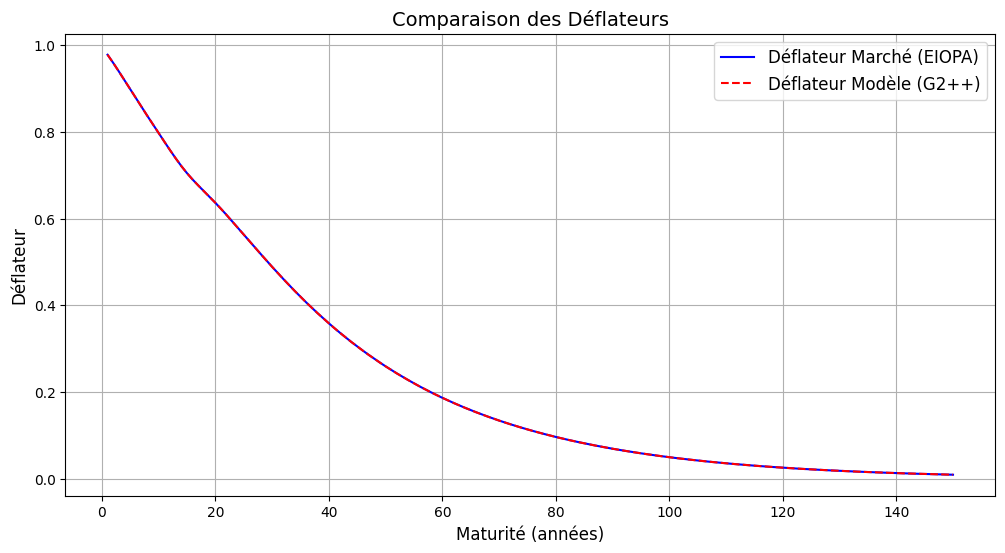


=== Statistiques d'erreur ===
Erreur RMS: 0.000049
Erreur maximale: 0.45 bps
Erreur moyenne: 0.22 bps


In [3]:
# ====================== FONCTION POUR CALCULER LES DEFLATEURS G2++ ======================
def g2pp_discount_factor(t, a, b, sigma, eta, rho):
    """Calcul du déflateur dans le modèle G2++"""
    # Calcul de l'intégrale de phi(s) de 0 à t
    def integrand(s):
        return phi(s, a, b, sigma, eta, rho)

    # Intégration numérique (méthode des trapèzes)
    n_points = 100
    s_values = np.linspace(0, t, n_points)
    integral = np.trapz([integrand(s) for s in s_values], s_values)

    # Calcul de la variance
    V = g2pp_variance(a, b, sigma, eta, rho, t)

    # Formule du déflateur dans G2++
    return np.exp(-integral + 0.5 * V)

# ====================== COMPARAISON DES DEFLATEURS ======================
print("\n=== Comparaison des Déflateurs ===")
print("Maturité\tDéflateur Marché\tDéflateur Modèle\tÉcart (bps)")
print("-" * 80)

# Calcul pour toutes les maturités EIOPA
for t in eiopa_times:
    market_df = discount_factor(t)
    model_df = g2pp_discount_factor(t, *params)

    # Conversion de l'écart en basis points
    spread_bps = (model_df - market_df) * 5000

    print(f"{t:>4.1f}\t\t{market_df:>12.6f}\t\t{model_df:>12.6f}\t\t{spread_bps:>8.2f}")

# Visualisation graphique
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(eiopa_times, [discount_factor(t) for t in eiopa_times], 'b-', label='Déflateur Marché (EIOPA)')
plt.plot(eiopa_times, [g2pp_discount_factor(t, *params) for t in eiopa_times], 'r--', label='Déflateur Modèle (G2++)')
plt.title('Comparaison des Déflateurs', fontsize=14)
plt.xlabel('Maturité (années)', fontsize=12)
plt.ylabel('Déflateur', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Calcul des erreurs
market_dfs = np.array([discount_factor(t) for t in eiopa_times])
model_dfs = np.array([g2pp_discount_factor(t, *params) for t in eiopa_times])

rms_error = np.sqrt(np.mean((market_dfs - model_dfs)**2))
max_error = np.max(np.abs(market_dfs - model_dfs)) * 5000
mean_error = np.mean(np.abs(market_dfs - model_dfs)) * 5000

print("\n=== Statistiques d'erreur ===")
print(f"Erreur RMS: {rms_error:.6f}")
print(f"Erreur maximale: {max_error:.2f} bps")
print(f"Erreur moyenne: {mean_error:.2f} bps")

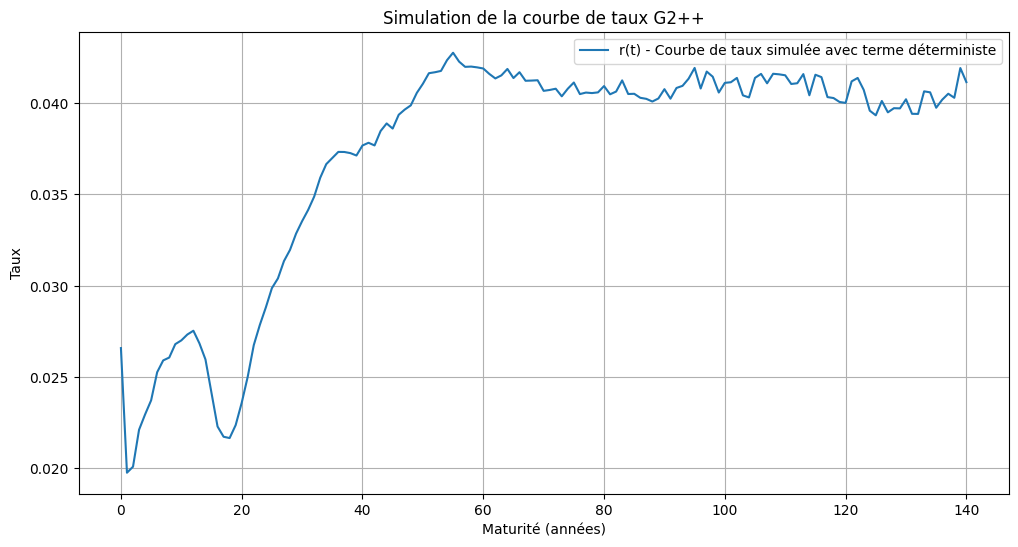

In [4]:
a,b,sigma,eta,rho = params
T=140
N = 140  # nombre de pas de temps
dt = T / N  # discrétisation du temps
t_grid = np.linspace(0, T, N + 1)

list_r = []

for i in range (3000):
        
    # Génération des mouvements browniens corrélés W1 et W2
    dW1 = np.random.normal(0, np.sqrt(dt), N)
    dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

    W1 = np.concatenate(([0], np.cumsum(dW1)))
    W2 = np.concatenate(([0], np.cumsum(dW2)))

    # Simulation des processus x(t) et y(t)
    x = np.zeros(N + 1)
    y = np.zeros(N + 1)


    for t in range(1, N + 1):
        x[t] = x[t-1] * np.exp(-a * dt) + sigma * np.sqrt((1 - np.exp(-2*a*dt)) / (2*a)) * W1[t]
        y[t] = y[t-1] * np.exp(-b * dt) + eta * np.sqrt((1 - np.exp(-2*b*dt)) / (2*b)) * W2[t]


    r = {t : x[t_idx] + y[t_idx] + phi(t,a,b,sigma,eta,rho) for t_idx, t in enumerate(t_grid)}
    list_r.append(r)

r_mean ={t : np.mean([r[t] for r in list_r ]) for t in t_grid}

plt.figure(figsize=(12, 6))
plt.plot(list(r_mean.keys()), list(r_mean.values()), label='r(t) - Courbe de taux simulée avec terme déterministe')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++')
plt.grid()
plt.show()

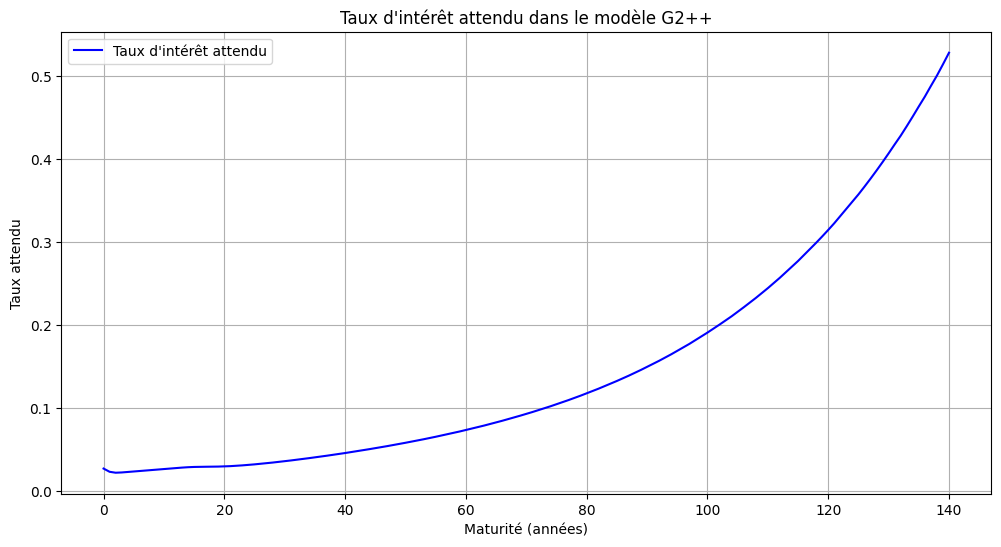

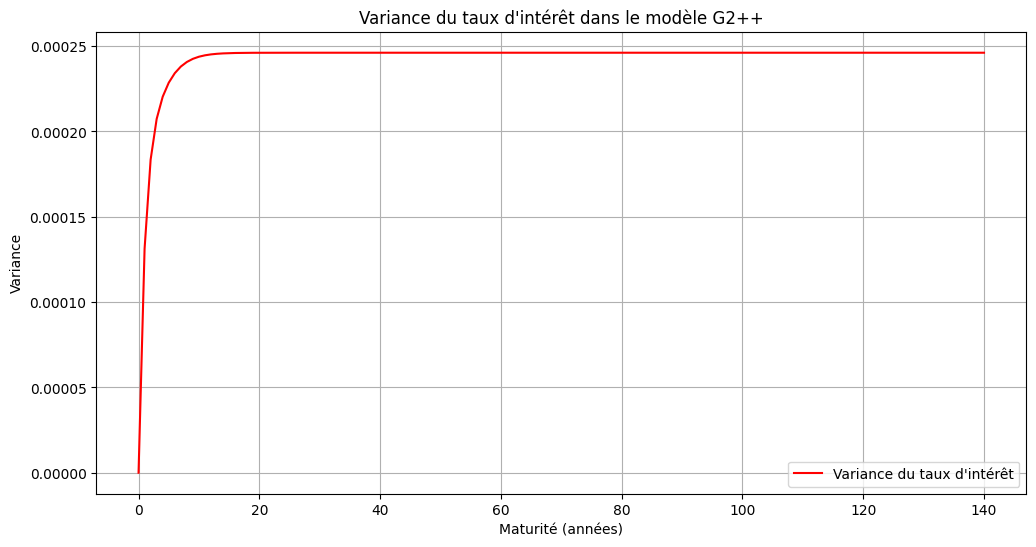

In [5]:
def expected_rate(t,a,b,sigma,eta,rho):
    """Calcul du taux d'intérêt attendu à maturité t dans le modèle G2++"""
    return compute_forward_rate(0, t) + ( sigma**2/(2*(a**2)) )*( (1 - np.exp(-a*t))**2 ) + eta**2/(2*(b**2))*( (1 - np.exp(-b*t))**2 ) + (rho*sigma*eta/(a*b))*(1 - np.exp(-a*t))*(1 - np.exp(-b*t))

def variance_rate(t,a,b,sigma,eta,rho):
    """Calcul de la variance du taux d'intérêt dans le modèle G2++"""
    return ( sigma**2/(2*(a)) )*(1 - np.exp(-2*a*t)) + eta**2/(2*(b))*(1 - np.exp(-2*b*t)) + (2*rho*sigma*eta/(a+b))*(1 - np.exp(-(a+b)*t))

# Calcul des taux d'intérêt attendus et des variances pour t dans t_grid
expected_rates = [expected_rate(t, a, b, sigma, eta, rho) for t in t_grid]
variances = [variance_rate(t, a, b, sigma, eta, rho) for t in t_grid]

# Tracé du taux d'intérêt attendu
plt.figure(figsize=(12, 6))
plt.plot(t_grid, expected_rates, label="Taux d'intérêt attendu", color='blue')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux attendu')
plt.title('Taux d\'intérêt attendu dans le modèle G2++')
plt.legend()
plt.grid()
plt.show()

# Tracé de la variance
plt.figure(figsize=(12, 6))
plt.plot(t_grid, variances, label="Variance du taux d'intérêt", color='red')
plt.xlabel('Maturité (années)')
plt.ylabel('Variance')
plt.title('Variance du taux d\'intérêt dans le modèle G2++')
plt.legend()
plt.grid()
plt.show()
